# OOF analysis: LLM2CLIP EVA02-L-14-336

Identity-disjoint 5-fold OOF for `runs/cv/eva02_trial23` (Hydra `current_best_tuned`).
This notebook looks at the **raw embeddings**, then how **postprocessing** and **TTA** move them.

Protocol: GroupKFold by `vehicle_id`, one query per identity from a held-out camera, gallery is all other cameras of that identity plus every other val identity. Metrics are cross-camera (`exclude_all_same_camera=true`). The official test set is unlabeled open-set (1110 query / 750 gallery); this OOF is not a simulator of that split, only a labeled proxy.

`mAP` is full-gallery average precision (checkpoint / Optuna). `mAP@10` is the official submission metric: AP over the top-10 gallery hits, divided by `min(n_pos, 10)`.

Scale TTA is forbidden for this backbone (fixed 336). TTA here is hflip, small rotations, and extra bbox context crops.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from dataset.images import crop_bbox, image_path
from modules.metrics import retrieval_metrics
from postproc.retrieval import aqe, k_reciprocal, normalize

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "data" / "train.csv").is_file())
CV = ROOT / "runs" / "cv" / "eva02_trial23"
IMAGES = ROOT / "data" / "images"
CONTEXT = 6.201741080661072
print("ROOT", ROOT)
print("CV", CV)

/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT /data/projects/ryzhichkin/ReID
CV /data/projects/ryzhichkin/ReID/runs/cv/eva02_trial23


/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


## Load OOF folds, TTA views, and sweep summaries

In [2]:
def load_pack(directory):
    oof = pd.read_csv(directory / "oof.csv", dtype={"image_id": str})
    query = pd.read_csv(directory / "query.csv", dtype={"image_id": str})
    gallery = pd.read_csv(directory / "gallery.csv", dtype={"image_id": str})
    emb = normalize(np.load(directory / "embeddings.npy"))
    lookup = {image_id: i for i, image_id in enumerate(oof.image_id)}
    qe = emb[[lookup[i] for i in query.image_id]]
    ge = emb[[lookup[i] for i in gallery.image_id]]
    return {"oof": oof, "query": query, "gallery": gallery, "emb": emb, "qe": qe, "ge": ge, "lookup": lookup}


def metric_args(pack):
    return dict(
        qids=pack["query"].vehicle_id.to_numpy(),
        gids=pack["gallery"].vehicle_id.to_numpy(),
        qcams=pack["query"].camera_id.to_numpy(),
        gcams=pack["gallery"].camera_id.to_numpy(),
        ranks=(1, 5, 10),
        cross_camera=True,
        exclude_all_same_camera=True,
    )


def score(qe, ge, pack):
    return retrieval_metrics(1.0 - qe @ ge.T, **metric_args(pack))


FOLDS = {fold: load_pack(CV / f"fold{fold}" / "val") for fold in range(5)}
TTA_VIEWS = ("hflip", "rot4", "hflip_rot4", "ctx_train", "leftover_full")
TTA = {
    name: {fold: load_pack(CV / "tta" / name / f"fold{fold}" / "val") for fold in range(5) if (CV / "tta" / name / f"fold{fold}" / "val" / "embeddings.npy").is_file()}
    for name in TTA_VIEWS
}
POST = pd.DataFrame([
    {"family": "postproc", "name": row["name"], "mAP": row["query_weighted_mean"]["mAP"], "Rank-1": row["query_weighted_mean"]["Rank-1"]}
    for row in json.loads((CV / "postproc_oof.json").read_text())["ranking"]
])
EXTRA = pd.DataFrame([
    {"family": "extra", "name": row["name"], "mAP": row["mean"]["mAP"], "Rank-1": row["mean"]["Rank-1"]}
    for row in json.loads((CV / "postproc_oof_extra.json").read_text())["ranking"]
])
TTA_SUM = pd.DataFrame([
    {
        "family": "tta",
        "name": row["name"],
        "n_folds": row["n_folds"],
        "mAP": row["query_weighted"]["mAP"],
        "mAP@10": row["query_weighted"].get("mAP@10"),
        "Rank-1": row["query_weighted"]["Rank-1"],
    }
    for row in json.loads((CV / "tta" / "tta_oof.json").read_text())["ranking"]
])
CV_METRICS = json.loads((CV / "cv_metrics.json").read_text())["metrics"]
BASELINE = float(CV_METRICS["mAP"]["query_weighted_mean"])
BASELINE_AT10 = float(CV_METRICS["mAP@10"]["query_weighted_mean"])
print("baseline OOF mAP", round(BASELINE, 4), "mAP@10", round(BASELINE_AT10, 4))
print("loaded folds", {fold: (len(p["query"]), len(p["gallery"]), p["emb"].shape) for fold, p in FOLDS.items()})
print("TTA views with 5 folds", {k: len(v) for k, v in TTA.items()})


baseline OOF mAP 0.8572 mAP@10 0.8454
loaded folds {0: (309, 1142, (1940, 256)), 1: (308, 1110, (1915, 256)), 2: (308, 1100, (1898, 256)), 3: (308, 1090, (1884, 256)), 4: (308, 1112, (1919, 256))}
TTA views with 5 folds {'hflip': 5, 'rot4': 5, 'hflip_rot4': 5, 'ctx_train': 5, 'leftover_full': 5}


## What the val split looks like

Each fold holds out a disjoint set of identities. One image becomes the query; remaining cross-camera images of that identity sit in the gallery together with every other val image. Same-camera gallery hits are masked at metric time, so a query cannot score using a near-duplicate from the same camera.

,fold,images,identities,cameras,n_query,n_gallery,pos_min,pos_median,pos_mean,pos_max,mAP,mAP@10,Rank-1
0,0,1940,309,90,309,1142,1,3.0000,3.6958,7,0.8583,0.8440,0.8576
1,1,1915,308,91,308,1110,1,3.0000,3.6039,7,0.8488,0.8382,0.8474
2,2,1898,308,90,308,1100,1,3.0000,3.5714,7,0.8588,0.8499,0.8474
3,3,1884,308,91,308,1090,1,3.0000,3.5390,7,0.8484,0.8324,0.8409
4,4,1919,308,87,308,1112,1,3.0000,3.6104,7,0.8717,0.8626,0.8734


query-weighted OOF mAP 0.8572018654029497 mAP@10 0.8454032932301914


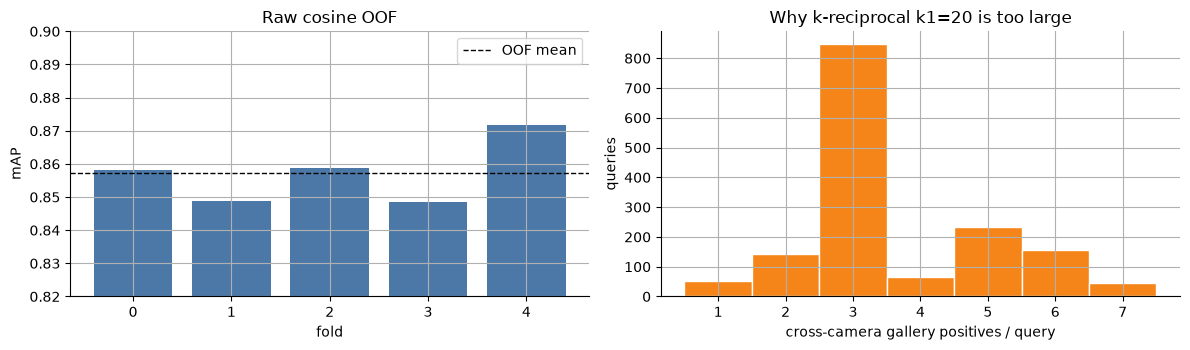

In [3]:
protocol_rows = []
pos_counts = []
for fold, pack in FOLDS.items():
    q, g = pack["query"], pack["gallery"]
    n_pos = []
    for i, qid in enumerate(q.vehicle_id):
        same_id = g.vehicle_id.to_numpy() == qid
        same_cam = g.camera_id.to_numpy() == q.camera_id.iloc[i]
        n_pos.append(int((same_id & ~same_cam).sum()))
    n_pos = np.asarray(n_pos)
    pos_counts.append(pd.DataFrame({"fold": fold, "n_pos": n_pos}))
    protocol_rows.append({
        "fold": fold,
        "images": len(pack["oof"]),
        "identities": pack["oof"].vehicle_id.nunique(),
        "cameras": pack["oof"].camera_id.nunique(),
        "n_query": len(q),
        "n_gallery": len(g),
        "pos_min": int(n_pos.min()),
        "pos_median": float(np.median(n_pos)),
        "pos_mean": float(n_pos.mean()),
        "pos_max": int(n_pos.max()),
        "mAP": score(pack["qe"], pack["ge"], pack)["mAP"],
        "mAP@10": score(pack["qe"], pack["ge"], pack)["mAP@10"],
        "Rank-1": score(pack["qe"], pack["ge"], pack)["Rank-1"],
    })
protocol = pd.DataFrame(protocol_rows)
pos_df = pd.concat(pos_counts, ignore_index=True)
display(protocol)
print("query-weighted OOF mAP", BASELINE, "mAP@10", BASELINE_AT10)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].bar(protocol.fold.astype(str), protocol.mAP, color="#4c78a8")
axes[0].axhline(BASELINE, color="black", ls="--", lw=1, label="OOF mean")
axes[0].set_ylim(0.82, 0.90)
axes[0].set_xlabel("fold")
axes[0].set_ylabel("mAP")
axes[0].set_title("Raw cosine OOF")
axes[0].legend()
axes[1].hist(pos_df.n_pos, bins=np.arange(0.5, pos_df.n_pos.max() + 1.5), color="#f58518", edgecolor="white")
axes[1].set_xlabel("cross-camera gallery positives / query")
axes[1].set_ylabel("queries")
axes[1].set_title("Why k-reciprocal k1=20 is too large")
plt.tight_layout()
plt.show()

## Scoreboard: raw vs postproc vs TTA

All numbers below are query-weighted 5-fold OOF except TTA recipes that only ran fold 0 (flagged). Postproc is transductive: it uses the full query+gallery feature set, not labels. The bar chart is full-gallery `mAP` (Optuna / checkpoint). `mAP@10` is listed for TTA and raw OOF.


,group,method,mAP,Rank-1,folds,mAP@10,delta_mAP
0,postproc,AQE q+g k=5,0.8692,0.8475,5,NaN,0.0120
1,postproc,DBA k=5 sim³,0.8677,0.8455,5,NaN,0.0105
2,postproc,AQE q+g 2 iter,0.8639,0.8410,5,NaN,0.0067
3,postproc,agg + GNN,0.8628,0.8410,5,NaN,0.0056
4,postproc,GNN rerank,0.8615,0.8417,5,NaN,0.0043
5,postproc,AQE gallery-only,0.8612,0.8410,5,NaN,0.0040
6,tta,TTA hflip+rot4,0.8596,0.8527,5,0.8482,0.0024
7,tta,TTA rot ±4°,0.8589,0.8546,5,0.8470,0.0017
8,tta,TTA hflip,0.8589,0.8540,5,0.8474,0.0017
9,postproc,AQE q+g 3 iter,0.8582,0.8326,5,NaN,0.0010


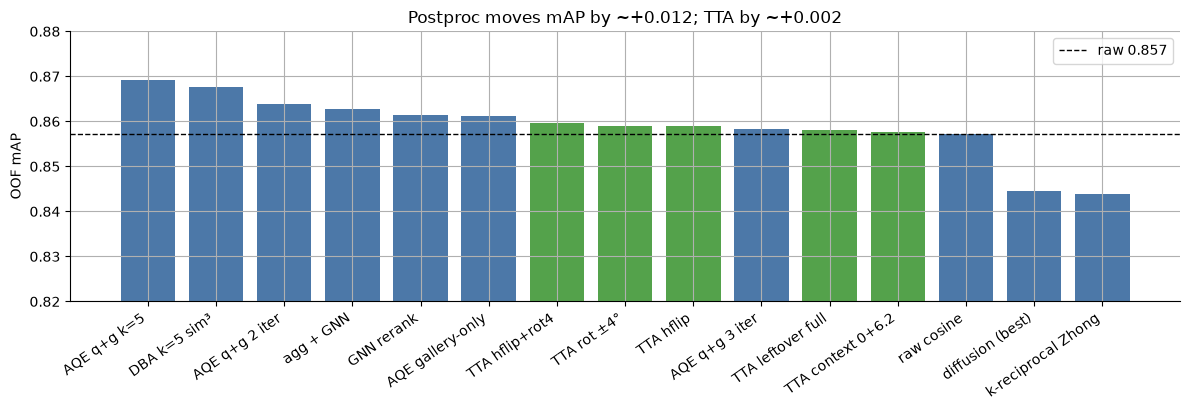

In [4]:
keep_post = {
    "default/baseline": "raw cosine",
    "default/aqe_query+gallery": "AQE q+g k=5",
    "default/aqe": "AQE gallery-only",
    "default/gnn": "GNN rerank",
    "default/agg+gnn": "agg + GNN",
    "default/k_reciprocal": "k-reciprocal Zhong",
}
keep_extra = {
    "DBA k=5 w^3": "DBA k=5 sim³",
    "AQE q+g iter=2": "AQE q+g 2 iter",
    "AQE q+g iter=3": "AQE q+g 3 iter",
    "diff sym k=50 a=0.8": "diffusion (best)",
}
keep_tta = {
    "hflip": "TTA hflip",
    "rot4": "TTA rot ±4°",
    "hflip_rot4": "TTA hflip+rot4",
    "leftover_full": "TTA leftover full",
    "ctx_train": "TTA context 0+6.2",
}
board = []
for raw, pretty in keep_post.items():
    row = POST[POST.name == raw].iloc[0]
    board.append({"group": "postproc", "method": pretty, "mAP": row.mAP, "Rank-1": row["Rank-1"], "folds": 5})
for raw, pretty in keep_extra.items():
    row = EXTRA[EXTRA.name == raw].iloc[0]
    board.append({"group": "postproc", "method": pretty, "mAP": row.mAP, "Rank-1": row["Rank-1"], "folds": 5})
for raw, pretty in keep_tta.items():
    row = TTA_SUM[TTA_SUM.name == raw].iloc[0]
    board.append({"group": "tta", "method": pretty, "mAP": row.mAP, "mAP@10": row["mAP@10"], "Rank-1": row["Rank-1"], "folds": int(row.n_folds)})
board = pd.DataFrame(board).drop_duplicates("method")
board["delta_mAP"] = board.mAP - BASELINE
board = board.sort_values("mAP", ascending=False).reset_index(drop=True)
display(board)

fig, ax = plt.subplots(figsize=(12, 4.2))
colors = {"postproc": "#4c78a8", "tta": "#54a24b"}
ax.bar(board.method, board.mAP, color=[colors[g] for g in board.group])
ax.axhline(BASELINE, color="black", ls="--", lw=1, label=f"raw {BASELINE:.3f}")
ax.set_ylim(0.82, 0.88)
ax.set_ylabel("OOF mAP")
ax.set_title("Postproc moves mAP by ~+0.012; TTA by ~+0.002")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")
ax.legend()
plt.tight_layout()
plt.show()

## Embedding space (fold 0)

256-D cosine embeddings, projected with PCA (linear global axes) and t-SNE (local neighborhoods). Points are val images of fold 0. Queries are the larger markers.

What to look for: identities form compact blobs across cameras; some cameras pull a whole slice of the space (viewpoint/background); hard identities sit in a crowded region of similar vehicles.

PCA fold0 explained variance [0.047 0.043]


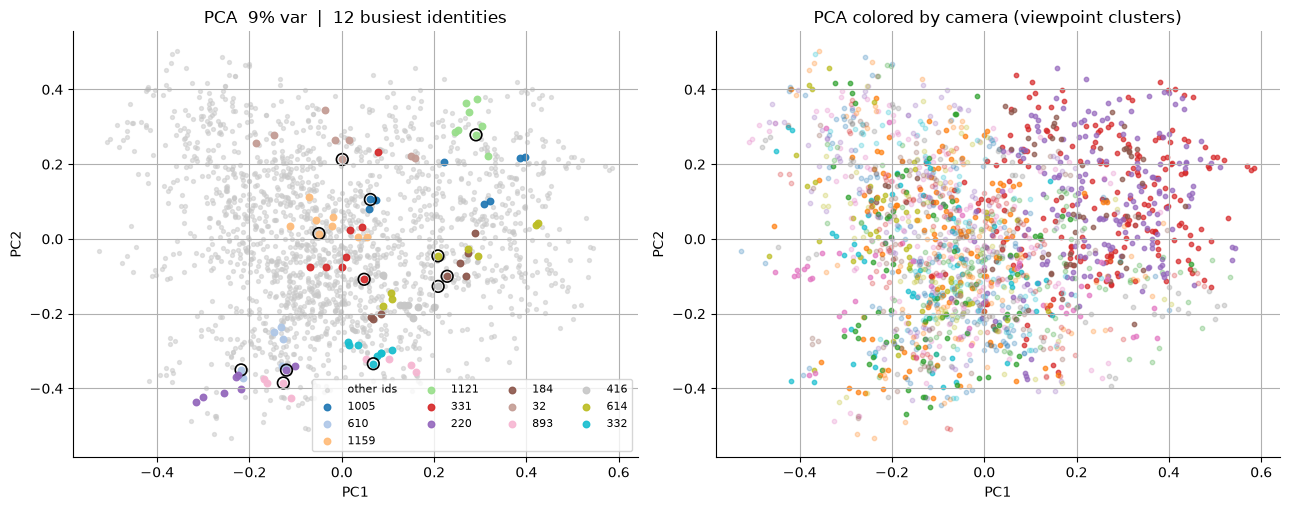

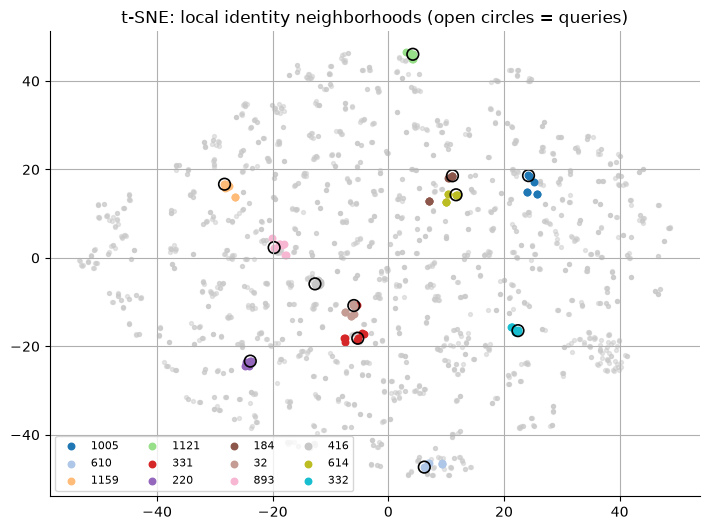

In [5]:
fold0 = FOLDS[0]
oof0 = fold0["oof"].copy()
emb0 = fold0["emb"]
pca = PCA(n_components=2, random_state=0).fit(emb0)
xy = pca.transform(emb0)
oof0["x1"], oof0["x2"] = xy[:, 0], xy[:, 1]
oof0["is_query"] = oof0.image_id.isin(set(fold0["query"].image_id))
print("PCA fold0 explained variance", pca.explained_variance_ratio_.round(3))

tsne = TSNE(n_components=2, perplexity=40, init="pca", learning_rate="auto", random_state=0, max_iter=500)
tsne_xy = tsne.fit_transform(PCA(n_components=32, random_state=0).fit_transform(emb0))
oof0["t1"], oof0["t2"] = tsne_xy[:, 0], tsne_xy[:, 1]

top_ids = oof0.vehicle_id.value_counts().head(12).index.tolist()
id_color = {vid: plt.cm.tab20(i / 12) for i, vid in enumerate(top_ids)}
cam_top = oof0.camera_id.value_counts().head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].scatter(oof0.x1, oof0.x2, s=8, c="#c8c8c8", alpha=0.5, label="other ids")
for vid in top_ids:
    part = oof0[oof0.vehicle_id == vid]
    axes[0].scatter(part.x1, part.x2, s=22, color=id_color[vid], label=str(vid), alpha=0.9)
    qpart = part[part.is_query]
    axes[0].scatter(qpart.x1, qpart.x2, s=70, facecolors="none", edgecolors="black", linewidths=1.2)
axes[0].set_title(f"PCA  {pca.explained_variance_ratio_.sum():.0%} var  |  12 busiest identities")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(ncol=4, fontsize=8, loc="best")

for cam in oof0.camera_id.unique():
    part = oof0[oof0.camera_id == cam]
    axes[1].scatter(part.x1, part.x2, s=10, alpha=0.7 if cam in cam_top else 0.25)
axes[1].set_title("PCA colored by camera (viewpoint clusters)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.scatter(oof0.t1, oof0.t2, s=8, c="#c8c8c8", alpha=0.45)
for vid in top_ids:
    part = oof0[oof0.vehicle_id == vid]
    ax.scatter(part.t1, part.t2, s=22, color=id_color[vid], label=str(vid))
    qpart = part[part.is_query]
    ax.scatter(qpart.t1, qpart.t2, s=70, facecolors="none", edgecolors="black", linewidths=1.2)
ax.set_title("t-SNE: local identity neighborhoods (open circles = queries)")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## Cosine geometry: positives vs distractors

Retrieval is 1 − cosine. Same-identity cross-camera pairs are the only pairs that count as positives. Same-camera pairs of the same identity are **excluded** (near-duplicates). The overlap between positive and negative cosine distributions is the actual error mass.

{'n_pos': 1142, 'n_same_cam_id': 0, 'n_neg': 340569, 'pos_mean': 0.6754989499673116, 'same_cam_mean': None, 'neg_mean': -0.0007862240810670918, 'neg_p99': 0.3586615753173831, 'pos_p10': 0.45100704431533817}


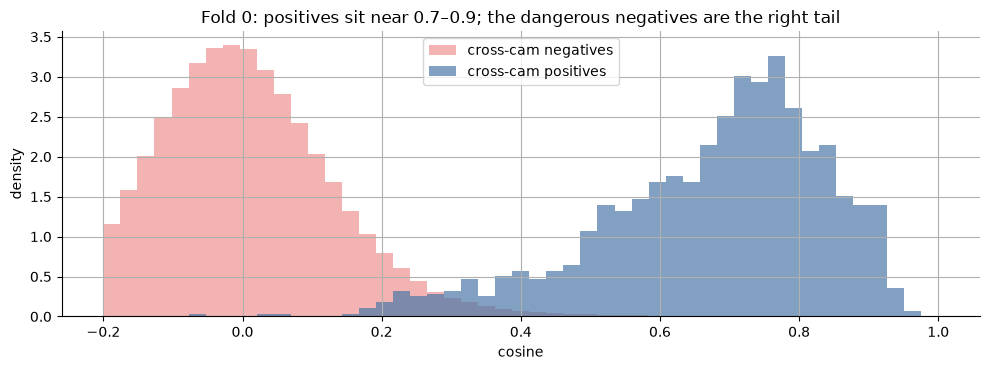

mean fraction of true id in top-5 cross-cam neighbors 0.5852044127190136


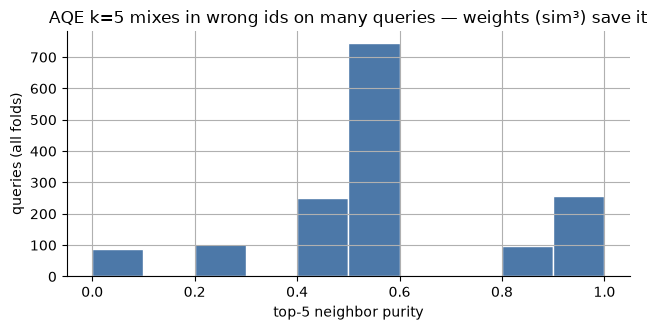

In [6]:
def pair_cosines(pack):
    sim = pack["qe"] @ pack["ge"].T
    q, g = pack["query"], pack["gallery"]
    pos, same_cam, neg = [], [], []
    for i in range(len(q)):
        same_id = g.vehicle_id.to_numpy() == q.vehicle_id.iloc[i]
        same_c = g.camera_id.to_numpy() == q.camera_id.iloc[i]
        pos.extend(sim[i, same_id & ~same_c].tolist())
        same_cam.extend(sim[i, same_id & same_c].tolist())
        neg.extend(sim[i, ~same_id & ~same_c].tolist())
    return np.asarray(pos), np.asarray(same_cam), np.asarray(neg)


pos, same_cam, neg = pair_cosines(fold0)
print({
    "n_pos": len(pos),
    "n_same_cam_id": len(same_cam),
    "n_neg": len(neg),
    "pos_mean": float(pos.mean()),
    "same_cam_mean": float(same_cam.mean()) if len(same_cam) else None,
    "neg_mean": float(neg.mean()),
    "neg_p99": float(np.quantile(neg, 0.99)),
    "pos_p10": float(np.quantile(pos, 0.10)),
})

fig, ax = plt.subplots(figsize=(10, 3.8))
bins = np.linspace(-0.2, 1.0, 50)
ax.hist(neg, bins=bins, density=True, alpha=0.45, label="cross-cam negatives", color="#e45756")
ax.hist(pos, bins=bins, density=True, alpha=0.7, label="cross-cam positives", color="#4c78a8")
if len(same_cam):
    ax.hist(same_cam, bins=bins, density=True, alpha=0.45, label="same-cam same-id (masked)", color="#54a24b")
ax.set_xlabel("cosine")
ax.set_ylabel("density")
ax.set_title("Fold 0: positives sit near 0.7–0.9; the dangerous negatives are the right tail")
ax.legend()
plt.tight_layout()
plt.show()

rng = np.random.default_rng(0)
neg_sample = rng.choice(neg, size=min(8000, len(neg)), replace=False)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(rng.choice(np.arange(len(neg_sample)), len(neg_sample)), neg_sample, s=4, alpha=0.15, c="#e45756")
ax.set_title("unused")
plt.close(fig)

knn_purity = []
for pack in FOLDS.values():
    sim = pack["qe"] @ pack["ge"].T
    gids = pack["gallery"].vehicle_id.to_numpy()
    gcams = pack["gallery"].camera_id.to_numpy()
    qids = pack["query"].vehicle_id.to_numpy()
    qcams = pack["query"].camera_id.to_numpy()
    for i in range(len(qids)):
        keep = gcams != qcams[i]
        idx = np.argsort(-sim[i, keep], kind="stable")[:5]
        knn_purity.append(float((gids[keep][idx] == qids[i]).mean()))
print("mean fraction of true id in top-5 cross-cam neighbors", float(np.mean(knn_purity)))
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(knn_purity, bins=np.linspace(0, 1, 11), color="#4c78a8", edgecolor="white")
ax.set_xlabel("top-5 neighbor purity")
ax.set_ylabel("queries (all folds)")
ax.set_title("AQE k=5 mixes in wrong ids on many queries — weights (sim³) save it")
plt.tight_layout()
plt.show()

## Per-query AP: easy vs hard cases

Full-gallery mAP is the mean of per-query average precision over every positive. Official `mAP@10` stops at rank 10 and divides by `min(n_pos, 10)`, so a positive at rank 11 contributes 0. A few collapsed identities drag the mean more than Rank-1 suggests. Below: AP histogram, AP vs number of positives, then crops for the worst and best queries (query | Rank-1 | first true positive).


                   count   mean     std    min    25%    50%    75%      max
ap             1541.0000 0.8572  0.2620 0.0039 0.8333 1.0000 1.0000   1.0000
n_pos          1541.0000 3.6042  1.3729 1.0000 3.0000 3.0000 5.0000   7.0000
rank_first_pos 1541.0000 2.5678 11.4751 1.0000 1.0000 1.0000 1.0000 265.0000
Rank-1 accuracy 0.8533419857235561 queries with AP<0.5 207 of 1541


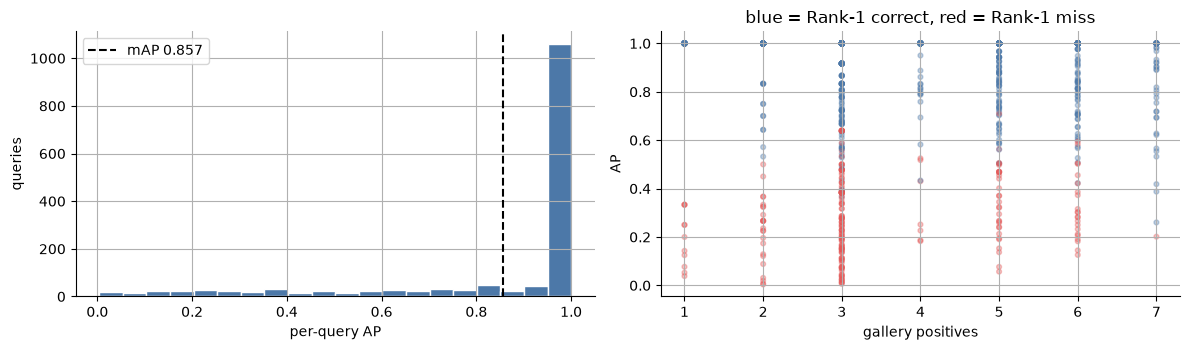

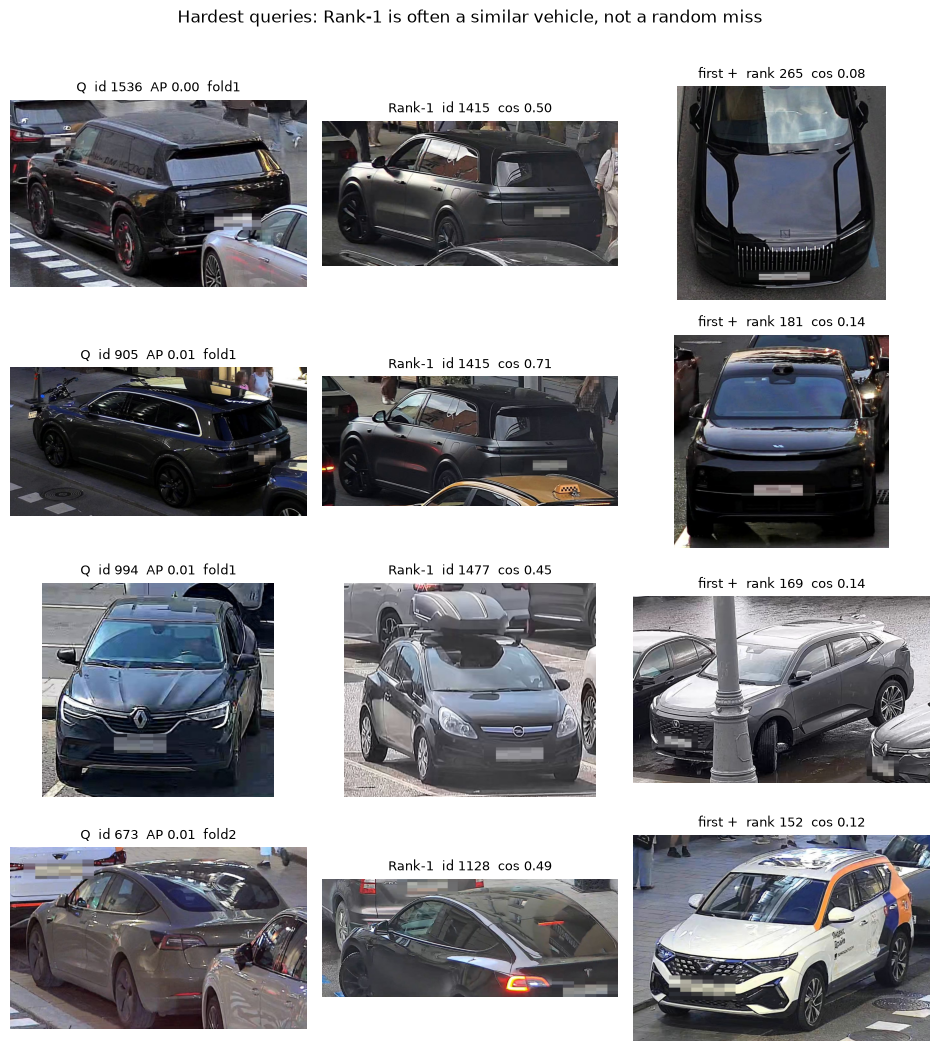

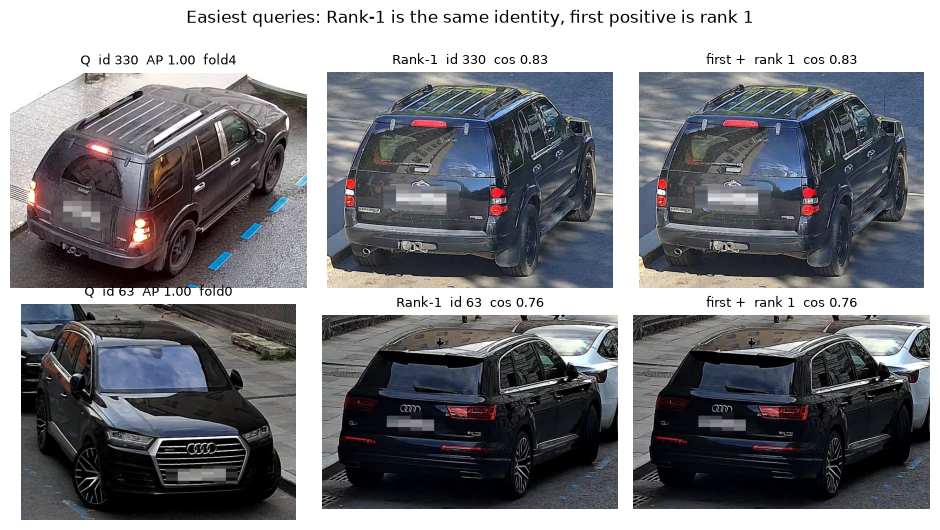

In [7]:
def query_rows(pack, qe=None, ge=None):
    qe = pack["qe"] if qe is None else qe
    ge = pack["ge"] if ge is None else ge
    q, g = pack["query"], pack["gallery"]
    dist = 1.0 - qe @ ge.T
    rows = []
    for i in range(len(q)):
        keep = g.camera_id.to_numpy() != q.camera_id.iloc[i]
        order = np.argsort(dist[i], kind="stable")
        order = order[keep[order]]
        relevant = g.vehicle_id.to_numpy()[order] == q.vehicle_id.iloc[i]
        found = np.flatnonzero(relevant)
        if len(found) == 0:
            continue
        first_pos = int(order[found[0]])
        rows.append({
            "q_index": i,
            "image_id": q.image_id.iloc[i],
            "vehicle_id": int(q.vehicle_id.iloc[i]),
            "camera_id": int(q.camera_id.iloc[i]),
            "n_pos": int(relevant.sum()),
            "ap": float(np.mean(np.arange(1, len(found) + 1) / (found + 1))),
            "rank1_ok": bool(relevant[0]),
            "rank_first_pos": int(found[0] + 1),
            "r1_index": int(order[0]),
            "r1_vehicle": int(g.vehicle_id.iloc[order[0]]),
            "r1_image": g.image_id.iloc[order[0]],
            "pos_image": g.image_id.iloc[first_pos],
            "pos_index": first_pos,
            "pos_cosine": float((qe[i] @ ge[first_pos])),
            "r1_cosine": float((qe[i] @ ge[order[0]])),
        })
    return pd.DataFrame(rows)


qtab = pd.concat([query_rows(FOLDS[fold]).assign(fold=fold) for fold in range(5)], ignore_index=True)
print(qtab[["ap", "n_pos", "rank_first_pos"]].describe().T)
print("Rank-1 accuracy", float(qtab.rank1_ok.mean()), "queries with AP<0.5", int((qtab.ap < 0.5).sum()), "of", len(qtab))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(qtab.ap, bins=20, color="#4c78a8", edgecolor="white")
axes[0].axvline(qtab.ap.mean(), color="black", ls="--", label=f"mAP {qtab.ap.mean():.3f}")
axes[0].set_xlabel("per-query AP")
axes[0].set_ylabel("queries")
axes[0].legend()
axes[1].scatter(qtab.n_pos, qtab.ap, s=12, alpha=0.35, c=np.where(qtab.rank1_ok, "#4c78a8", "#e45756"))
axes[1].set_xlabel("gallery positives")
axes[1].set_ylabel("AP")
axes[1].set_title("blue = Rank-1 correct, red = Rank-1 miss")
plt.tight_layout()
plt.show()


def show_crop(row):
    with Image.open(image_path(IMAGES, row.image_id if hasattr(row, "image_id") else row)) as im:
        im = im.convert("RGB")
        if hasattr(row, "x"):
            return crop_bbox(im, [row.x, row.y, row.w, row.h], CONTEXT)
        return im


def row_by_id(frame, image_id):
    return frame.loc[frame.image_id == image_id].iloc[0]


def panel(ax, image_id, frame, title, edge=None):
    crop = show_crop(row_by_id(frame, image_id))
    ax.imshow(crop)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if edge:
        for spine in ax.spines.values():
            spine.set_edgecolor(edge)
            spine.set_linewidth(2)
            spine.set_visible(True)


def show_cases(table, title):
    fig, axes = plt.subplots(len(table), 3, figsize=(9.5, 2.6 * len(table)))
    if len(table) == 1:
        axes = np.array([axes])
    for r, rec in enumerate(table.itertuples()):
        pack = FOLDS[int(rec.fold)]
        qframe = pack["query"]
        gframe = pack["gallery"]
        panel(axes[r, 0], rec.image_id, qframe, f"Q  id {rec.vehicle_id}  AP {rec.ap:.2f}  fold{rec.fold}")
        edge = "#54a24b" if rec.rank1_ok else "#e45756"
        panel(axes[r, 1], rec.r1_image, gframe, f"Rank-1  id {rec.r1_vehicle}  cos {rec.r1_cosine:.2f}", edge=edge)
        panel(axes[r, 2], rec.pos_image, gframe, f"first +  rank {rec.rank_first_pos}  cos {rec.pos_cosine:.2f}", edge="#4c78a8")
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


hard = qtab.sort_values("ap").head(4)
easy = qtab.sort_values("ap", ascending=False).head(2)
show_cases(hard, "Hardest queries: Rank-1 is often a similar vehicle, not a random miss")
show_cases(easy, "Easiest queries: Rank-1 is the same identity, first positive is rank 1")

## Postprocessing on the embedding space

AQE replaces each vector by a similarity-weighted average of its top-k neighbors in the reference set. `gallery_only=false` lets queries expand using other queries as well as gallery (legal here: the full test query set is given). DBA does the same only on gallery. k-reciprocal reranks distances instead of moving points.

The PCA below is **fitted on raw fold-0 embeddings** and then used to project AQE vectors, so arrows are in a fixed space.

fold0 raw {'mAP': 0.8583035982026107, 'mAP@10': 0.8439809035804182, 'mINP': 0.8123225957663704, 'Rank-1': 0.8576051779935275, 'Rank-5': 0.9385113268608414, 'Rank-10': 0.9676375404530745, 'evaluated_queries': 309, 'queries_without_positive': 0}
fold0 AQE q+g {'mAP': 0.8657608753021446, 'mAP@10': 0.8530491527786951, 'mINP': 0.8481269101538634, 'Rank-1': 0.8381877022653722, 'Rank-5': 0.9320388349514563, 'Rank-10': 0.9611650485436893, 'evaluated_queries': 309, 'queries_without_positive': 0}
fold0 AQE gallery {'mAP': 0.8656212917558055, 'mAP@10': 0.8526705694863347, 'mINP': 0.8433288474793235, 'Rank-1': 0.8478964401294499, 'Rank-5': 0.9255663430420712, 'Rank-10': 0.9579288025889967, 'evaluated_queries': 309, 'queries_without_positive': 0}
fold0 k-reciprocal {'mAP': 0.8476699420060747, 'mAP@10': 0.8339101214020308, 'mINP': 0.8150723146612477, 'Rank-1': 0.8446601941747572, 'Rank-5': 0.9223300970873787, 'Rank-10': 0.9676375404530745, 'evaluated_queries': 309, 'queries_without_positive': 0}
AQE

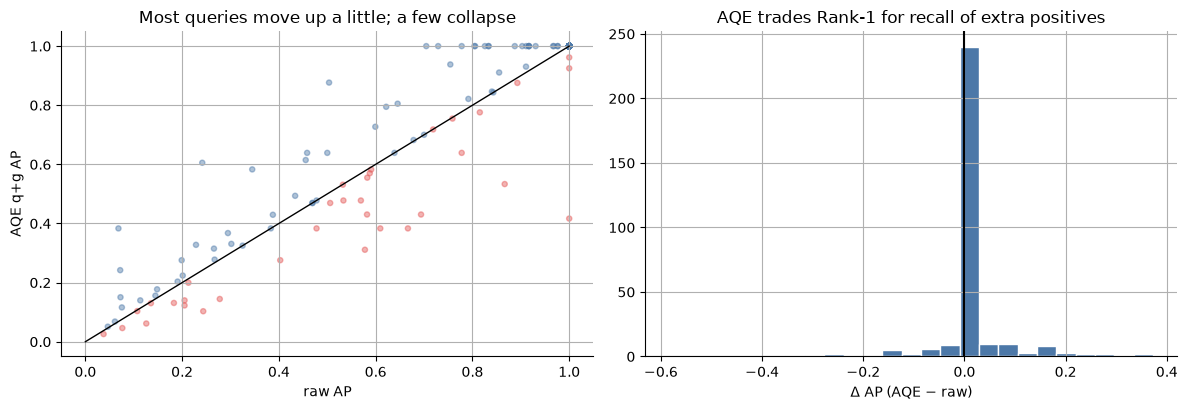

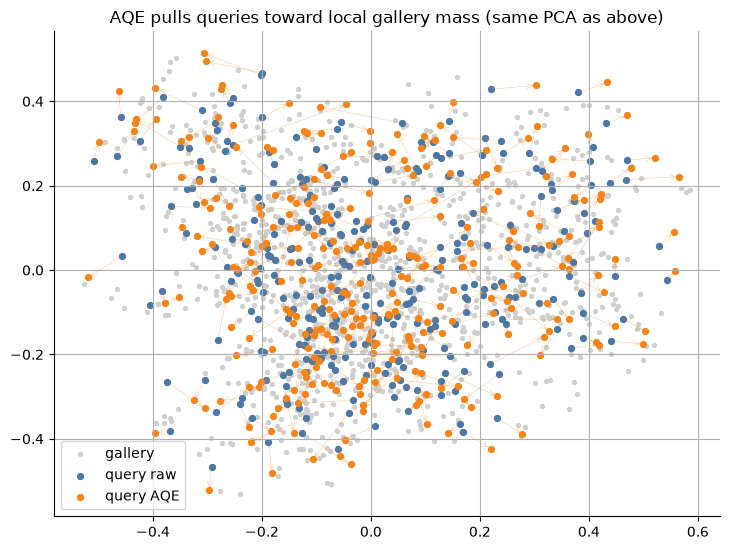

largest |Δ AP| queries


,q_index,ap_raw,r1_raw,rank_raw,n_pos,ap_aqe,r1_aqe,ap_gal,d_aqe
34,34,1.0000,True,1,2,0.4167,False,0.4167,-0.5833
70,70,0.5037,False,2,5,0.8767,True,0.8767,0.3730
1,1,0.2416,False,3,5,0.6054,True,0.4693,0.3638
131,131,0.8667,True,1,3,0.5333,False,1.0000,-0.3333
58,58,0.0684,False,25,3,0.3833,False,0.3833,0.3149
242,242,0.7045,True,1,6,1.0000,True,1.0000,0.2955
142,142,0.6667,True,1,3,0.3833,False,0.3833,-0.2833
17,17,0.7292,True,1,3,1.0000,True,1.0000,0.2708


In [8]:
raw_q, raw_g = fold0["qe"], fold0["ge"]
aqe_q, aqe_g = aqe(raw_q, raw_g, k=5, alpha=3.0, iterations=1, gallery_only=False)
aqe_gal_q, aqe_gal_g = aqe(raw_q, raw_g, k=5, alpha=3.0, iterations=1, gallery_only=True)
krec = k_reciprocal(raw_q, raw_g, k1=20, k2=6, lambda_value=0.3)
raw_tab = query_rows(fold0, raw_q, raw_g)
aqe_tab = query_rows(fold0, aqe_q, aqe_g)
gal_tab = query_rows(fold0, aqe_gal_q, aqe_gal_g)
krec_metrics = retrieval_metrics(krec, **metric_args(fold0))
cmp = raw_tab[["q_index", "ap", "rank1_ok", "rank_first_pos", "n_pos"]].rename(columns={"ap": "ap_raw", "rank1_ok": "r1_raw", "rank_first_pos": "rank_raw"})
cmp["ap_aqe"] = aqe_tab.ap.to_numpy()
cmp["r1_aqe"] = aqe_tab.rank1_ok.to_numpy()
cmp["ap_gal"] = gal_tab.ap.to_numpy()
cmp["d_aqe"] = cmp.ap_aqe - cmp.ap_raw
print("fold0 raw", score(raw_q, raw_g, fold0))
print("fold0 AQE q+g", score(aqe_q, aqe_g, fold0))
print("fold0 AQE gallery", score(aqe_gal_q, aqe_gal_g, fold0))
print("fold0 k-reciprocal", krec_metrics)
print("AQE helps", int((cmp.d_aqe > 1e-6).sum()), "hurts", int((cmp.d_aqe < -1e-6).sum()), "mean Δ", float(cmp.d_aqe.mean()))
print("Rank-1 raw → AQE", float(cmp.r1_raw.mean()), "→", float(cmp.r1_aqe.mean()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(cmp.ap_raw, cmp.ap_aqe, s=14, alpha=0.45, c=np.where(cmp.d_aqe >= 0, "#4c78a8", "#e45756"))
axes[0].plot([0, 1], [0, 1], color="black", lw=1)
axes[0].set_xlabel("raw AP")
axes[0].set_ylabel("AQE q+g AP")
axes[0].set_title("Most queries move up a little; a few collapse")
axes[1].hist(cmp.d_aqe, bins=25, color="#4c78a8", edgecolor="white")
axes[1].axvline(0, color="black")
axes[1].set_xlabel("Δ AP (AQE − raw)")
axes[1].set_title("AQE trades Rank-1 for recall of extra positives")
plt.tight_layout()
plt.show()

q_xy = pca.transform(raw_q)
g_xy = pca.transform(raw_g)
aqe_q_xy = pca.transform(aqe_q)
fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.scatter(g_xy[:, 0], g_xy[:, 1], s=8, c="#d0d0d0", label="gallery")
ax.scatter(q_xy[:, 0], q_xy[:, 1], s=18, c="#4c78a8", label="query raw")
ax.scatter(aqe_q_xy[:, 0], aqe_q_xy[:, 1], s=18, c="#f58518", label="query AQE")
for src, dst in zip(q_xy, aqe_q_xy):
    ax.annotate("", xy=dst, xytext=src, arrowprops=dict(arrowstyle="->", color="#f58518", lw=0.5, alpha=0.35))
ax.set_title("AQE pulls queries toward local gallery mass (same PCA as above)")
ax.legend()
plt.tight_layout()
plt.show()

print("largest |Δ AP| queries")
display(cmp.reindex(cmp.d_aqe.abs().sort_values(ascending=False).index).head(8))

## TTA: how the vector actually moves

Each TTA recipe averages normalized embeddings of flipped / rotated / re-cropped views, then renormalizes. If views agree, the averaged vector barely moves and cosine to the raw embedding stays ~1. Large moves mean the crop is view-sensitive (truncation, blur, yaw).

hflip mean cosine vs raw 0.9984245896339417 p01 0.9946354627609253
rot4 mean cosine vs raw 0.9948416352272034 p01 0.983860194683075
hflip_rot4 mean cosine vs raw 0.9939379096031189 p01 0.9807419180870056


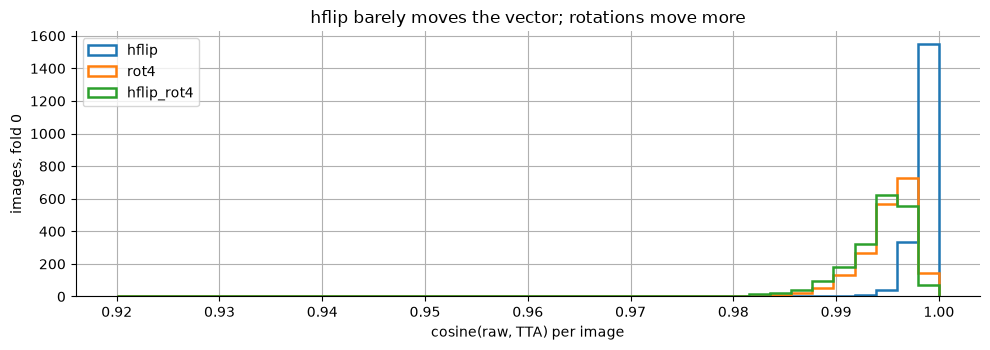

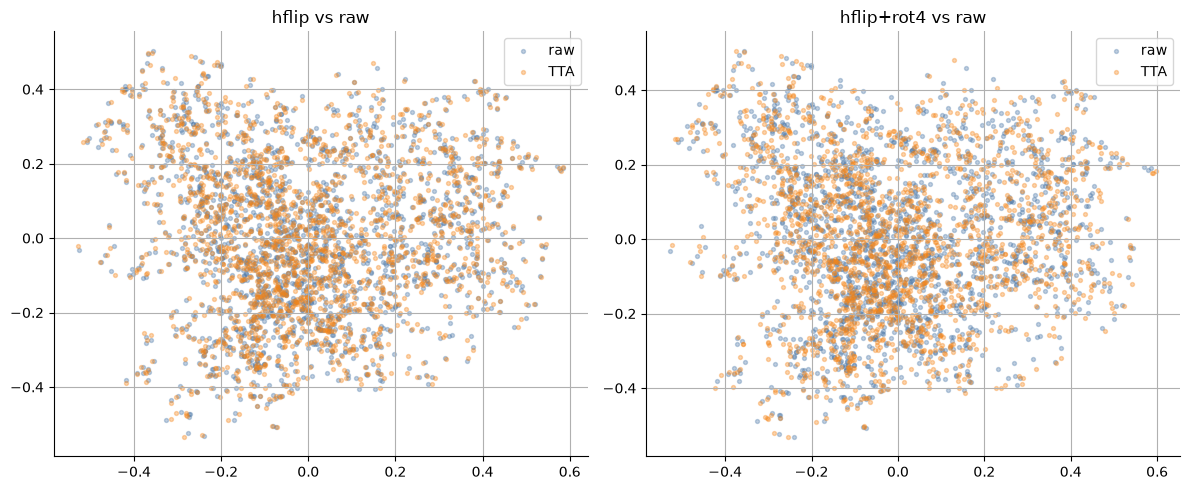

hflip+rot4 ΔAP mean 0.002444917192576854 helps 228 hurts 190
Rank-1 raw → TTA 0.8533419857235561 → 0.8526930564568462


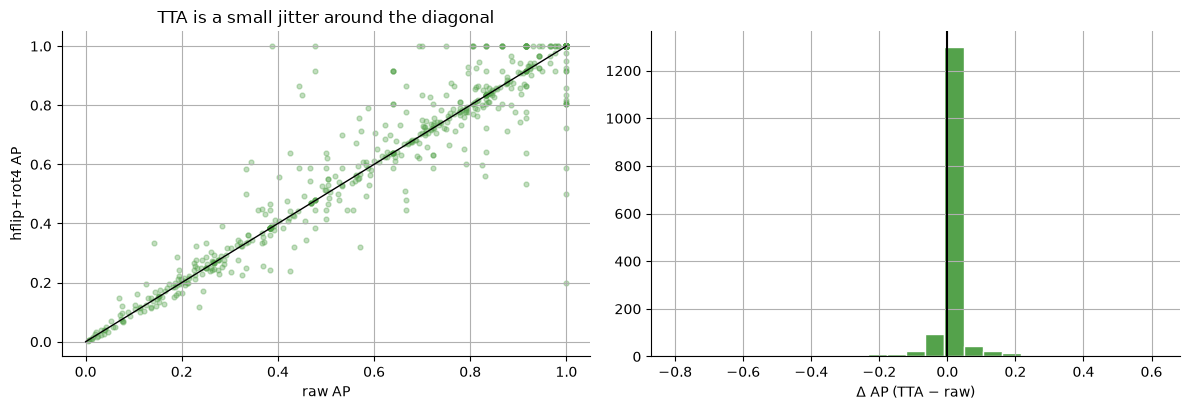

OOF mAP TTA hflip+rot4 + AQE q+g 0.8721222863591382
vs AQE on raw 0.8692096593011105


In [9]:
def aligned_emb(name, fold):
    base = FOLDS[fold]
    view = TTA[name][fold]
    order = [view["lookup"][i] for i in base["oof"].image_id]
    return view["emb"][order]


tta_cos = {}
for name in ("hflip", "rot4", "hflip_rot4"):
    if 0 not in TTA[name]:
        continue
    moved = aligned_emb(name, 0)
    tta_cos[name] = np.sum(emb0 * moved, axis=1)
    print(name, "mean cosine vs raw", float(tta_cos[name].mean()), "p01", float(np.quantile(tta_cos[name], 0.01)))

fig, ax = plt.subplots(figsize=(10, 3.6))
bins = np.linspace(0.92, 1.0, 40)
for name, vals in tta_cos.items():
    ax.hist(vals, bins=bins, histtype="step", lw=1.8, label=name)
ax.set_xlabel("cosine(raw, TTA) per image")
ax.set_ylabel("images, fold 0")
ax.set_title("hflip barely moves the vector; rotations move more")
ax.legend()
plt.tight_layout()
plt.show()

hflip_xy = pca.transform(aligned_emb("hflip", 0))
rot_xy = pca.transform(aligned_emb("hflip_rot4", 0))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, new_xy, title in (
    (axes[0], hflip_xy, "hflip vs raw"),
    (axes[1], rot_xy, "hflip+rot4 vs raw"),
):
    ax.scatter(xy[:, 0], xy[:, 1], s=8, c="#4c78a8", alpha=0.35, label="raw")
    ax.scatter(new_xy[:, 0], new_xy[:, 1], s=8, c="#f58518", alpha=0.35, label="TTA")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

tta_delta = []
for fold in range(5):
    raw_t = query_rows(FOLDS[fold])
    tta_pack = TTA["hflip_rot4"][fold]
    tta_t = query_rows(tta_pack)
    part = raw_t[["image_id", "ap", "rank1_ok"]].merge(
        tta_t[["image_id", "ap", "rank1_ok"]], on="image_id", suffixes=("_raw", "_tta")
    )
    part["fold"] = fold
    tta_delta.append(part)
tta_delta = pd.concat(tta_delta, ignore_index=True)
tta_delta["d_ap"] = tta_delta.ap_tta - tta_delta.ap_raw
print("hflip+rot4 ΔAP mean", float(tta_delta.d_ap.mean()), "helps", int((tta_delta.d_ap > 1e-6).sum()), "hurts", int((tta_delta.d_ap < -1e-6).sum()))
print("Rank-1 raw → TTA", float(tta_delta.rank1_ok_raw.mean()), "→", float(tta_delta.rank1_ok_tta.mean()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(tta_delta.ap_raw, tta_delta.ap_tta, s=12, alpha=0.35, c="#54a24b")
axes[0].plot([0, 1], [0, 1], color="black", lw=1)
axes[0].set_xlabel("raw AP")
axes[0].set_ylabel("hflip+rot4 AP")
axes[0].set_title("TTA is a small jitter around the diagonal")
axes[1].hist(tta_delta.d_ap, bins=25, color="#54a24b", edgecolor="white")
axes[1].axvline(0, color="black")
axes[1].set_xlabel("Δ AP (TTA − raw)")
plt.tight_layout()
plt.show()

aqe_on_tta = []
for fold in range(5):
    pack = TTA["hflip_rot4"][fold]
    qe, ge = aqe(pack["qe"], pack["ge"], k=5, alpha=3.0, iterations=1, gallery_only=False)
    aqe_on_tta.append(score(qe, ge, pack))
print("OOF mAP TTA hflip+rot4 + AQE q+g", float(np.mean([row["mAP"] for row in aqe_on_tta])))
print("vs AQE on raw", float(POST.loc[POST.name == "default/aqe_query+gallery", "mAP"].iloc[0]))

## Takeaways

- Raw 5-fold OOF is **mAP 0.857** / **mAP@10 0.845**. Optuna and best checkpoints still track full mAP; mAP@10 is the contest number.
- The embedding space is already well clustered by identity. PCA/t-SNE show compact vehicles; residual errors are **near-miss lookalikes**, not random gallery junk.
- Same-camera same-id cosines are higher than cross-camera positives. The metric correctly hides that shortcut.
- Median ~3 true gallery hits per query. That is why Zhong k-reciprocal with k1=20 **hurts**: the reciprocal neighborhood is mostly other identities.
- **AQE query+gallery** is the only postproc with a clear +0.012 mAP. It slides queries toward local mass, lifting extra positives, and slightly **drops Rank-1**.
- Extra AQE iterations, unweighted DBA, and diffusion oversmooth the same small graph and lose the gain.
- **TTA** (hflip ± small rotation) is a ~+0.002 mAP jitter. Context-crop TTA is not useful. Scale TTA is not available for LLM2CLIP.
- Stacking **TTA hflip+rot4 + AQE q+g** reaches OOF mAP **0.872**, a bit above AQE on raw embeddings (0.869). AQE still does the heavy lifting.

`current_best_tuned` leaves both TTA and postproc **off**. Enable AQE q+g at submission time if the competition allows transductive use of the full query set.
